In [45]:
import os
import re
import pickle
import numpy as np
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# read in atlases
atlas_base_path = "/home/zachkaras/fmri/fmri_model/analysis/pipeline/atlases"

# read in 2d mni mask
mask = nib.load(f"{atlas_base_path}/MNI152_T1_2mm_brain_mask.nii.gz")
og_shape = mask.shape
mask = mask.get_fdata().flatten()
brain_idx = np.where(mask>0)[0]

atlas = nib.load(f"{atlas_base_path}/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
atlas_vec = atlas.get_fdata().flatten()
atlas_only_brain = atlas_vec[brain_idx] # contains the schaefer parcel numbers
cortex_vx = np.where(atlas_only_brain != 0)[0]
parcel_nums = atlas_only_brain[cortex_vx]

# Making empty templates to save output
empty_schaefer = np.zeros(atlas_only_brain.shape)
empty_mni = np.zeros(atlas_vec.shape)


In [37]:
class Regression_Info(object):
    # [model_name, task, look_ahead, n_delays, layer, stat]
    def __init__(self, model_name=None, task=None, look_ahead=None, n_delays=None, layer=None, stat=None):
        self.model_name = model_name
        self.task       = task
        self.look_ahead = look_ahead
        self.n_delays   = n_delays
        self.layer      = layer
        self.stat       = stat
        
    def __str__(self):
        return f"{self.model_name}, {self.task}, {self.look_ahead}, {self.n_delays}, {self.layer}, {self.stat}"

def nested_dict():
        return defaultdict(nested_dict)

def convert_to_nifti(values):
    # working backwards to save correlation values as voxels in MNI space
    empty_schaefer[cortex_vx] = values
    empty_mni[brain_idx] = empty_schaefer
    result_brain = np.reshape(empty_mni, og_shape)

    # Saving results
    nifti_result = nib.Nifti1Image(result_brain, affine=atlas.affine, header=atlas.header)
    nib.save(nifti_result, "test_plotting.nii.gz")
    return result_brain, nifti_result


def parse_regression_info(path):
    
    parts = path.split('-') 
    # example: ['codegemma_7b', 'code', 'look_ahead_by_1', 'ndelays_0', 'layer_28', 'correlations.pkl']
    info = Regression_Info()
    info.model_name = parts[0]
    info.task       = parts[1]
    info.look_ahead = parts[2]
    info.n_delays   = parts[3]
    info.layer      = parts[4]
    info.stat       = (parts[5])[:-4]
    
    return info


def find_cutoff(vec, threshold = 10**4):
    
    # I can find the threshold point based on sorting, then keep everything in the same place
    copy = vec.copy()
    copy.sort()
    cutoff = copy[-threshold-1]
    return cutoff


def iterate_through_participants(filepath, stat):
    participants = os.listdir(filepath)
    
    stat_collection = nested_dict()
    
    # iterating through participants
    for p in participants:
        print(p)
        datapath = f"{filepath}/{p}"
        files = os.listdir(datapath)
        stat_files = [f for f in files if re.search(stat, f)]
        
        # iterating through the stat files
        # these are vectors of correlation coefficients between predicted and recorded signal
        # Different parameters were adjusted, so the folder contains all the possibilities
        # [model_name, task, look_ahead, n_delays, layer, stat]
        for sf in stat_files:
            
            info = parse_regression_info(sf)
            
            stat_file = f"{datapath}/{sf}"
            with open(stat_file, 'rb') as f:
                try:
                    stat_vec = pickle.load(f)
                except:
                    print(f"issue with {p}: {sf}")
                
            # filter to top 10k, 10k is default parameter but can be changed with threshold argument
            cutoff = find_cutoff(stat_vec)
            # print(len(stat_vec))
            top_voxel_idx = (np.where(stat_vec > cutoff))[0]
            top_voxel_vals = stat_vec[top_voxel_idx]
            top_parcels = parcel_nums[top_voxel_idx]
            # print(len(top_voxel_vals), top_voxel_vals)
            # plt.hist(top_parcels, bins=400)
            
            # save into big dictionary structure
            # 6 figures, one for each model
            # in 2 rows, one for each task
            
            # Should I keep one thing consistent, like only look at the best layer for a given model
            # and only the best performing participants?
            # It should depend on the research questions...
            # No I'd like to see across a range of participants
            # I feel like layer 
            if info.look_ahead not in stat_collection[info.task][info.model_name][info.n_delays].keys():
                stat_collection[info.task][info.model_name][info.n_delays][info.look_ahead]  = top_voxel_vals
            else:
                np.append(stat_collection[info.task][info.model_name][info.n_delays][info.look_ahead], top_voxel_vals)
            # print(stat_vec)
            # break
        # break
    
    return stat_collection
        
        

In [38]:
# iterate through directories, parse the file names, and accumulate stats

# parsing file names [model_name, task, look_ahead, n_delays, layer, stat]
filepath = "/storage1/fmri_model_data/ridge_regression_pca_params"
stat_collection = iterate_through_participants(filepath, 'correlations')



111
121
150
112
101
130
203
125
204
117
134
201
122
151
108
133
129
105
118
109
144
119
141
138
142


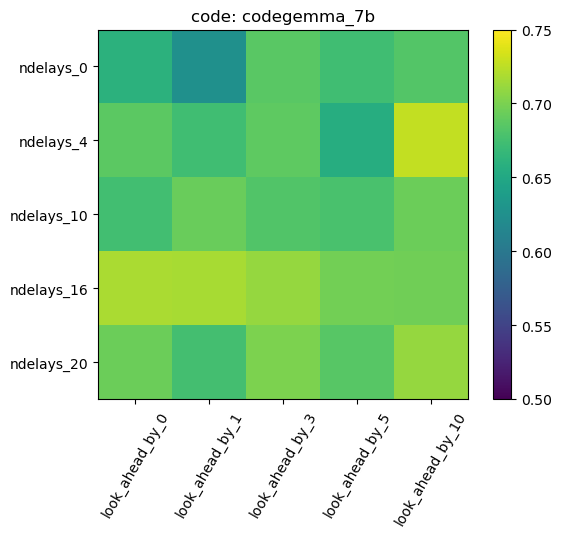

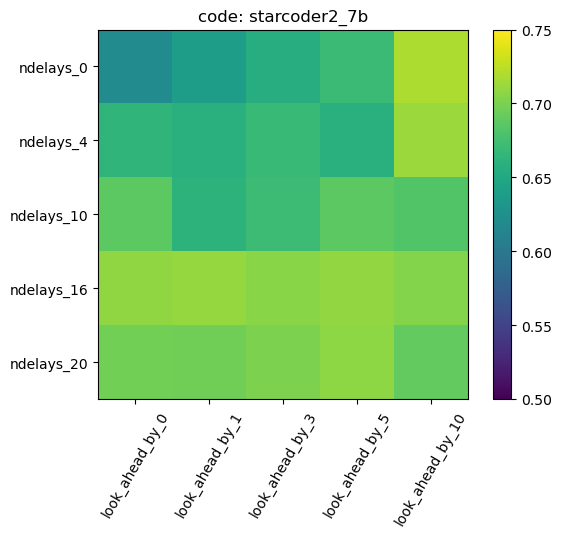

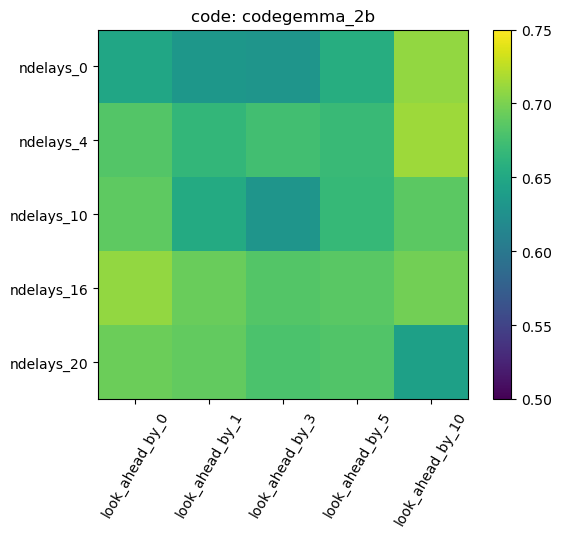

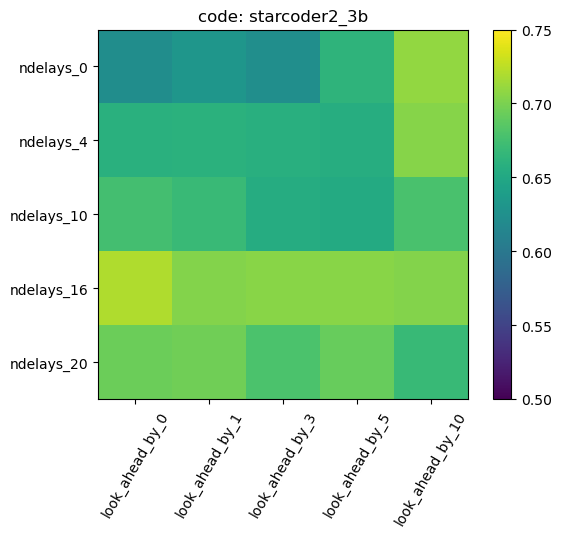

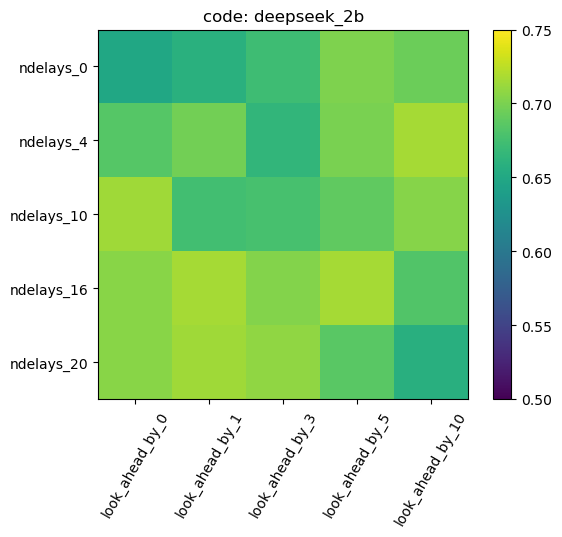

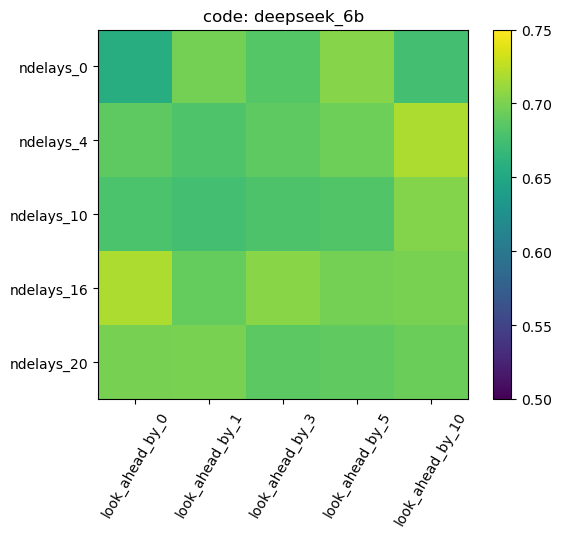

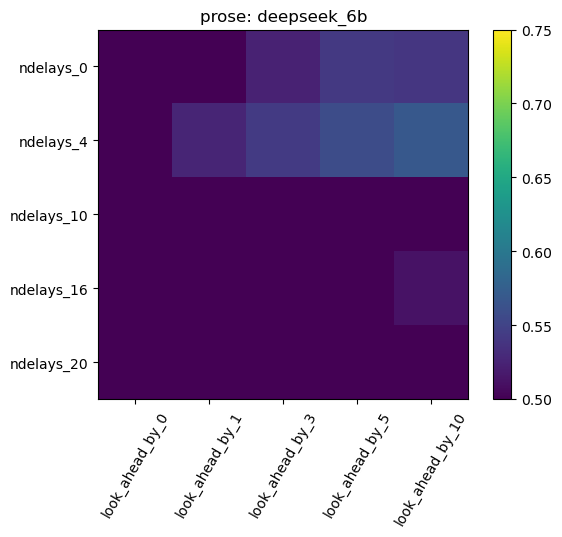

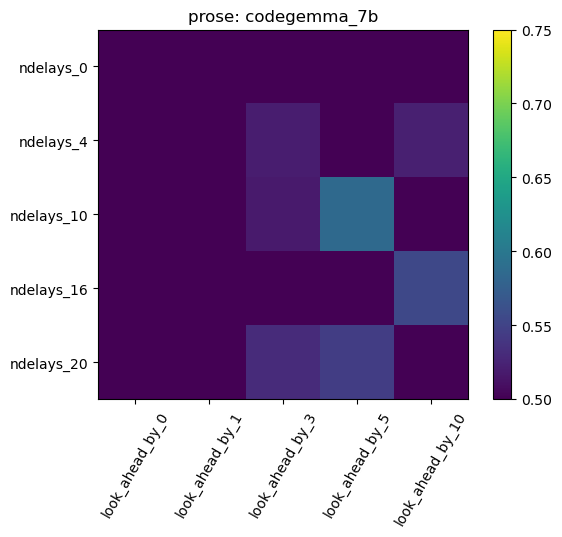

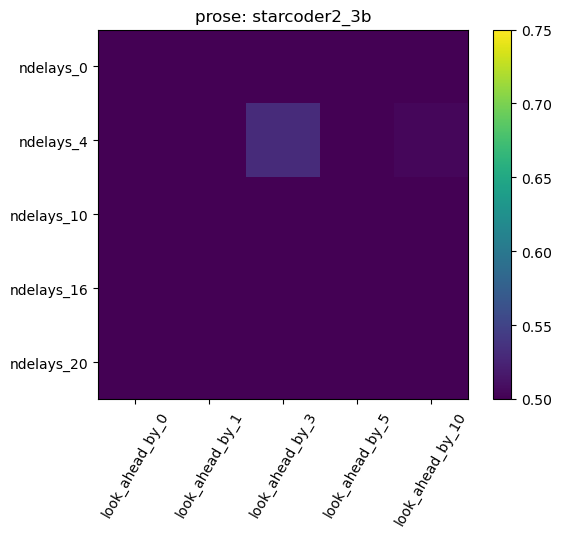

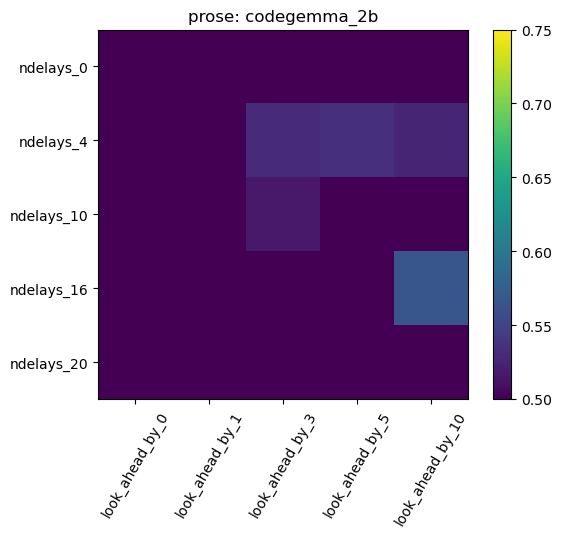

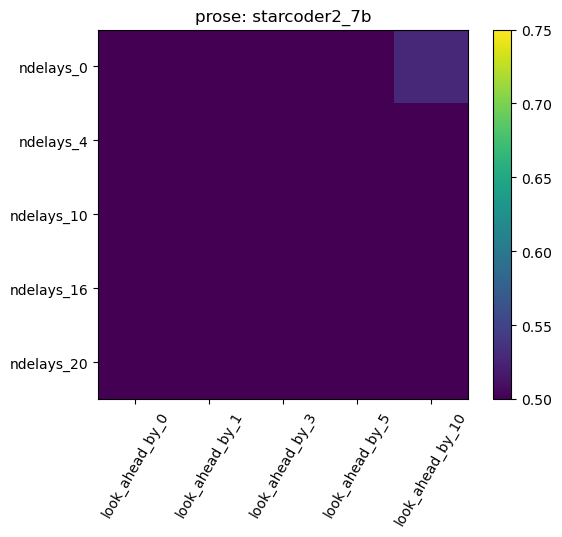

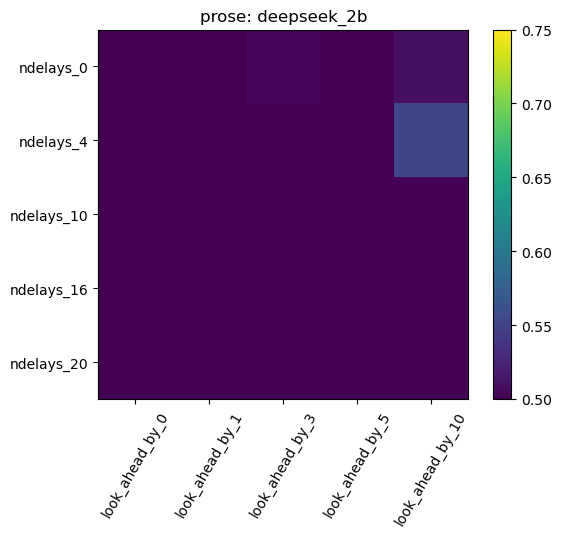

In [ ]:
# EXAMPLE: stat_collection[info.task][info.model_name][info.n_delays][info.look_ahead]
# need to iterate through dictionary structure

# param_ave = nested_dict()

for task, model_delay_peek_vals in stat_collection.items():
    for model, delay_peek_vals in model_delay_peek_vals.items():
        param_delays = []
        delay_nums = [0,4,10,16,20]
        delay_labels = [f"ndelays_{d}" for d in delay_nums]
        
        # delays = delay_peek_vals.keys()
        for dl in delay_labels:
            # for delay, peek_vals in delay_peek_vals.items():
            peek_vals = delay_peek_vals[dl]
            # print(delay)
            peek_nums = [0,1,3,5,10]
            peek_labels = [f'look_ahead_by_{p}' for p in peek_nums]
            
            param_averages = []
            # peeks = peek_vals.keys()
            for pl in peek_labels:
            # for peek, vals in peek_vals.items():
                vals = peek_vals[pl]
                # print(peek)
                # print(task, model, delay, peek, vals)
                # vals = stat_collection[task][model][delay][peek]
                # print(len(vals), vals)
                ave = np.mean(vals)
                param_averages.append(ave)
            param_delays.append(param_averages)
        
        # plotting code here
        # print(param_delays)
        plt.figure()
        plt.imshow(param_delays, vmin=0.5, vmax=0.75)
        plt.xticks(ticks=range(0,5), labels=peek_labels, rotation=60)
        plt.yticks(ticks=range(0,5), labels=delay_labels)
        plt.colorbar()
        title = f"{task}: {model}"
        plt.title(title)
        plt.savefig(f"results/{task}-{model}-heatmap.png", dpi=150)
        
        # plt.xlabel(delays)
        # plt.ylabel(peeks)
        # fig, ax = plt.subplots()
        
        # sns.heatmap(param_delays)
    #     break
    # break

        
                
            

# then average the arrays

# need to create a 2d data structure
# look ahead by as keys

In [55]:
list(range(1,5))

[1, 2, 3, 4]

In [ ]:
# create heatmaps to show modeling performance
def make_heatmap():
    pass

In [ ]:
# plot
for task, model_delay_peek_vals in param_ave.items():
    for model, delay_peek_vals in model_delay_peek_vals.items():
        for delay, peek_vals in delay_peek_vals.items():
            for peek, vals in peek_vals.items():
                delays = delay_peek_vals.keys()
                peeks = peek_vals.keys()
                print(delays, peeks)
                print(peek_vals.values())
            break
        break
    break
    

dict_keys(['ndelays_0', 'ndelays_16', 'ndelays_10', 'ndelays_4', 'ndelays_20']) dict_keys(['look_ahead_by_1', 'look_ahead_by_0', 'look_ahead_by_10', 'look_ahead_by_3', 'look_ahead_by_5'])
dict_values([0.625021287886603, 0.6611207984245097, 0.6831812698758524, 0.686187353263972, 0.6737777035535836])


In [ ]:
# maybe violin plots or word clouds to show predominant schaefer parcels